In [1]:
from __future__ import annotations
import matplotlib.pyplot as plt
import json
from itertools import combinations
from pathlib import Path

import joblib
import math
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score


def nurse_id_from_path(path: Path) -> str:
    return path.stem.replace("processed_nurse_", "")


def infer_window_steps(time_values: np.ndarray, window_seconds: float) -> int:
    if len(time_values) < 2:
        return 1
    diffs = np.diff(time_values)
    positive_diffs = diffs[diffs > 0]
    if len(positive_diffs) == 0:
        return 1
    dt = float(np.median(positive_diffs))
    return max(1, int(round(window_seconds / dt)))


def build_windows(
    X: np.ndarray,
    y: np.ndarray,
    window_steps: int,
    stride_steps: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if len(X) < window_steps:
        return np.empty((0, X.shape[1] * 6)), np.empty((0,), dtype=int), np.empty((0,), dtype=int)

    X_windows: list[np.ndarray] = []
    y_windows: list[int] = []
    end_indices: list[int] = []

    for start in range(0, len(X) - window_steps + 1, stride_steps):
        end = start + window_steps
        w = X[start:end]
        # Summarize local behavior over the window to keep dimensions compact.
        mean = w.mean(axis=0)
        std = w.std(axis=0)
        minv = w.min(axis=0)
        maxv = w.max(axis=0)
        last = w[-1]
        slope = (w[-1] - w[0]) / max(1, window_steps - 1)
        X_windows.append(np.concatenate([mean, std, minv, maxv, last, slope], axis=0))
        # Predict stress at the current endpoint from recent history.
        y_windows.append(int(y[end - 1]))
        end_indices.append(end - 1)

    return np.asarray(X_windows), np.asarray(y_windows), np.asarray(end_indices)


def load_and_process_nurse(
    csv_path: Path,
    window_seconds: float,
    fixed_window_steps: int | None,
    stride_fraction: float,
    test_ratio: float,
) -> dict[str, object] | None:
    df = pd.read_csv(csv_path)

    required_cols = {"time", "acc_mag", "EDA", "HR", "TEMP", "label"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{csv_path.name} is missing columns: {sorted(missing)}")

    df = df.sort_values("time").reset_index(drop=True)
    df["label_bin"] = (df["label"] > 0).astype(int)

    features = ["acc_mag", "EDA", "HR", "TEMP"]
    X = df[features].to_numpy(dtype=np.float32)
    y = df["label_bin"].to_numpy(dtype=np.int8)

    window_steps = (
        fixed_window_steps
        if fixed_window_steps is not None
        else infer_window_steps(df["time"].to_numpy(dtype=np.float32), window_seconds)
    )
    stride_steps = max(1, int(round(window_steps * stride_fraction)))

    Xw, yw, end_idx = build_windows(X, y, window_steps, stride_steps)
    if len(Xw) == 0:
        return None

    split_idx = int(len(Xw) * (1.0 - test_ratio))
    split_idx = min(max(split_idx, 1), len(Xw) - 1)

    nurse_id = nurse_id_from_path(csv_path)
    return {
        "nurse_id": nurse_id,
        "window_steps": int(window_steps),
        "stride_steps": int(stride_steps),
        "num_windows": int(len(Xw)),
        "X_train": Xw[:split_idx],
        "y_train": yw[:split_idx],
        "X_test": Xw[split_idx:],
        "y_test": yw[split_idx:],
        "test_end_idx": end_idx[split_idx:],
        "test_times": df.loc[end_idx[split_idx:], "time"].to_numpy(dtype=np.float32),
    }

In [3]:
def evaluate(model, data_loader, criterion, device):
    """Evaluate model on a dataset."""
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch).squeeze()
            loss = criterion(logits, y_batch.float())
            total_loss += loss.item() * len(X_batch)
            
            preds = (torch.sigmoid(logits) > 0.5).detach().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.detach().cpu().numpy())
    
    avg_loss = total_loss / len(data_loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    
    return avg_loss, accuracy, f1, all_preds, all_labels

In [3]:
import os
import glob
import numpy as np
import pandas as pd
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, f1_score
)
from sklearn.model_selection import GroupShuffleSplit
from google.colab import drive
drive.mount('/content/drive')
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Hyper-parameters ─────────────────────────────────────────────────────────
SEQ_LEN       = 200        # ~6 s of 32 Hz data
STRIDE        = 50         # step between windows
BATCH_SIZE    = 64
HIDDEN_SIZE   = 128
NUM_LAYERS    = 2
DROPOUT       = 0.3
LR            = 1e-3
EPOCHS        = 5
PATIENCE      = 5          # early-stopping patience
TRAIN_FRAC    = 0.7        # fraction of days used for training
VAL_FRAC      = 0.15       # remainder goes to test
DATA_DIR      = "/content/drive/My Drive/mlma"
RESULTS_DIR   = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

FEATURES = ["acc_mag", "EDA", "HR", "TEMP", "time_progress"]
TARGET   = "label_binary"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu


In [3]:
def load_nurse(path: str) -> pd.DataFrame:
    """Load one nurse CSV and apply all preprocessing steps."""
    df = pd.read_csv(path, parse_dates=["datetime"])

    # ── Binarize labels: 0 → no-stress, 1 & 2 → stress ──────────────────────
    df["label_binary"] = (df["label"] > 0).astype(int)

    # ── Extract date (day) for day-based splitting ────────────────────────────
    df["date"] = df["datetime"].dt.date

    # ── Add time_progress: fraction of the day elapsed (0 → 1) ───────────────
    df = df.sort_values("datetime").reset_index(drop=True)
    df["time_progress"] = (
        df.groupby("date")["time"]
          .transform(lambda t: (t - t.min()) / (t.max() - t.min() + 1e-9))
    )

    return df


def day_split(df: pd.DataFrame, train_frac: float = TRAIN_FRAC,
              val_frac: float = VAL_FRAC):
    """Split days into train / val / test.

    Test day is chosen as the day whose stress ratio is closest to 0.5
    (most balanced), so the test set always contains both classes.
    Val day is the most balanced among the remaining days.
    Train gets everything else.
    """
    days = sorted(df["date"].unique())

    # Balance score: closeness to 0.5 stress ratio (lower = more balanced)
    balance = df.groupby("date")["label_binary"].mean()
    scored  = sorted(days, key=lambda d: abs(balance[d] - 0.5))

    test_day = scored[0]                          # most balanced day → test
    remaining = [d for d in scored if d != test_day]

    val_day   = remaining[0] if remaining else None   # next most balanced → val
    train_days = [d for d in days if d not in {test_day, val_day}]

    train_df = df[df["date"].isin(train_days)]
    val_df   = df[df["date"].isin([val_day])]   if val_day   else df.iloc[:0]
    test_df  = df[df["date"].isin([test_day])]

    return train_df, val_df, test_df


def normalize_nurse(train_df, val_df, test_df, features=FEATURES):
    """Fit a StandardScaler on train split; transform all three splits."""
    scaler = StandardScaler()
    # Exclude time_progress from scaler (already in [0,1])
    scale_cols = [f for f in features if f != "time_progress"]

    train_df = train_df.copy()
    val_df   = val_df.copy()
    test_df  = test_df.copy()

    train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
    val_df[scale_cols]   = scaler.transform(val_df[scale_cols])
    test_df[scale_cols]  = scaler.transform(test_df[scale_cols])

    return train_df, val_df, test_df, scaler


# ─────────────────────────────────────────────────────────────────────────────
# 2.  SEQUENCE DATASET
# ─────────────────────────────────────────────────────────────────────────────

class SequenceDataset(Dataset):
    """Sliding-window dataset over a single nurse's data."""

    def __init__(self, df: pd.DataFrame, seq_len: int = SEQ_LEN,
                 stride: int = STRIDE):
        data   = df[FEATURES].values.astype(np.float32)
        labels = df[TARGET].values.astype(np.int64)

        self.X, self.y = [], []
        for start in range(0, len(data) - seq_len + 1, stride):
            end = start + seq_len
            self.X.append(data[start:end])
            # majority vote over the window
            window_labels = labels[start:end]
            self.y.append(int(window_labels.mean() >= 0.5))

        self.X = np.array(self.X)
        self.y = np.array(self.y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])


def make_loader(df, seq_len=SEQ_LEN, stride=STRIDE,
                batch_size=BATCH_SIZE, shuffle=True, oversample=False):
    ds = SequenceDataset(df, seq_len, stride)
    if len(ds) == 0:
        return None

    if oversample and shuffle:
        # WeightedRandomSampler: give each window a weight inverse to its class freq
        labels  = ds.y
        counts  = np.bincount(labels, minlength=2).astype(float)
        counts  = np.where(counts == 0, 1, counts)          # avoid div-by-zero
        w_per_class = 1.0 / counts
        weights = torch.tensor(w_per_class[labels], dtype=torch.float32)
        sampler = torch.utils.data.WeightedRandomSampler(
            weights, num_samples=len(weights), replacement=True
        )
        return DataLoader(ds, batch_size=batch_size,
                          sampler=sampler, drop_last=False)

    return DataLoader(ds, batch_size=batch_size,
                      shuffle=shuffle, drop_last=False)



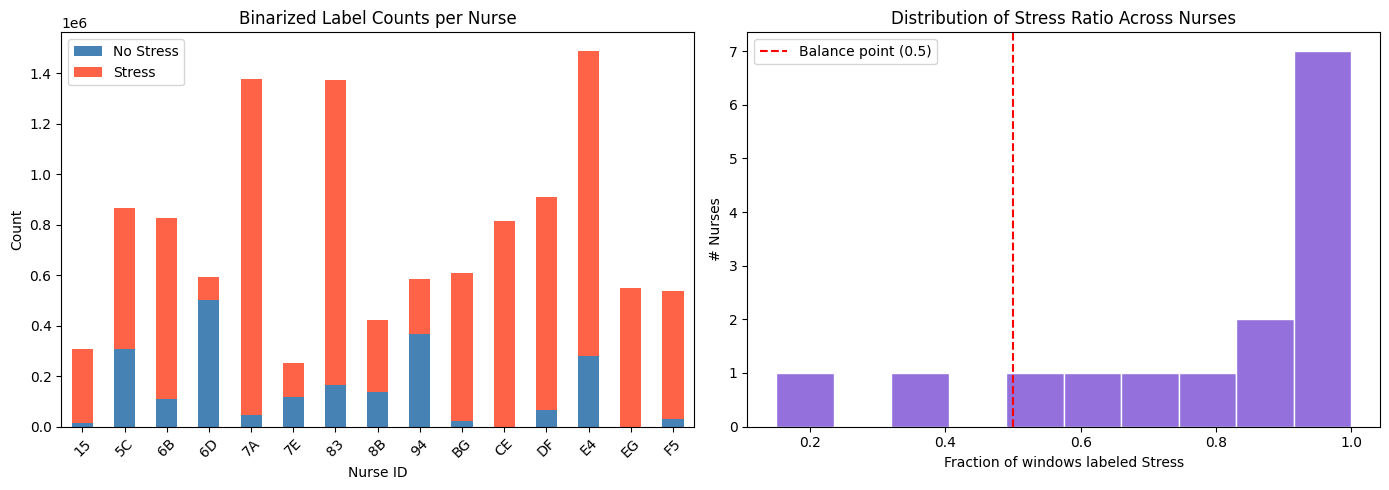

   nurse_id  stress_ratio
3        6D      0.149353
8        94      0.375268
5        7E      0.537876
1        5C      0.643018
7        8B      0.673773
12       E4      0.811012
2        6B      0.869757
6        83      0.881118
11       DF      0.928117
14       F5      0.942653
0        15      0.956520
9        BG      0.965297
4        7A      0.966543
10       CE      1.000000
13       EG      1.000000


In [4]:
import glob
import matplotlib.pyplot as plt
import pandas as pd
import re

def plot_label_distribution(data_dir: str, pattern: str = "*.csv", paths = None):
    """Load all nurse CSVs and plot binarized label distribution across all nurses."""
    
    all_dfs = []
    if paths is None:
        paths = glob.glob(f"{data_dir}/{pattern}")
        print('hi')
    
    for path in paths:
        df = load_nurse(path)
        match = re.search(r'([A-Z]+|\d+)(?=\.csv)', path.split("/")[-1])
        nurse_id = path.split("/")[-1].replace(".csv", "")[-2:]


        df["nurse_id"] = nurse_id
        all_dfs.append(df)
    
    combined = pd.concat(all_dfs, ignore_index=True)
    
    # ── Per-nurse stress ratio ────────────────────────────────────────────────
    per_nurse = (
        combined.groupby("nurse_id")["label_binary"]
        .mean()
        .reset_index()
        .rename(columns={"label_binary": "stress_ratio"})
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: stacked bar per nurse showing 0/1 counts
    counts = combined.groupby(["nurse_id", "label_binary"]).size().unstack(fill_value=0)
    counts.columns = ["No Stress", "Stress"]
    counts.plot(kind="bar", stacked=True, ax=axes[0], color=["steelblue", "tomato"])
    axes[0].set_title("Binarized Label Counts per Nurse")
    axes[0].set_xlabel("Nurse ID")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=45)
    
    # Right: histogram of stress ratios across nurses
    axes[1].hist(per_nurse["stress_ratio"], bins=10, color="mediumpurple", edgecolor="white")
    axes[1].axvline(0.5, color="red", linestyle="--", label="Balance point (0.5)")
    axes[1].set_title("Distribution of Stress Ratio Across Nurses")
    axes[1].set_xlabel("Fraction of windows labeled Stress")
    axes[1].set_ylabel("# Nurses")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return combined, per_nurse

csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
combined, per_nurse = plot_label_distribution(DATA_DIR, paths = csv_paths)
print(per_nurse.sort_values("stress_ratio"))


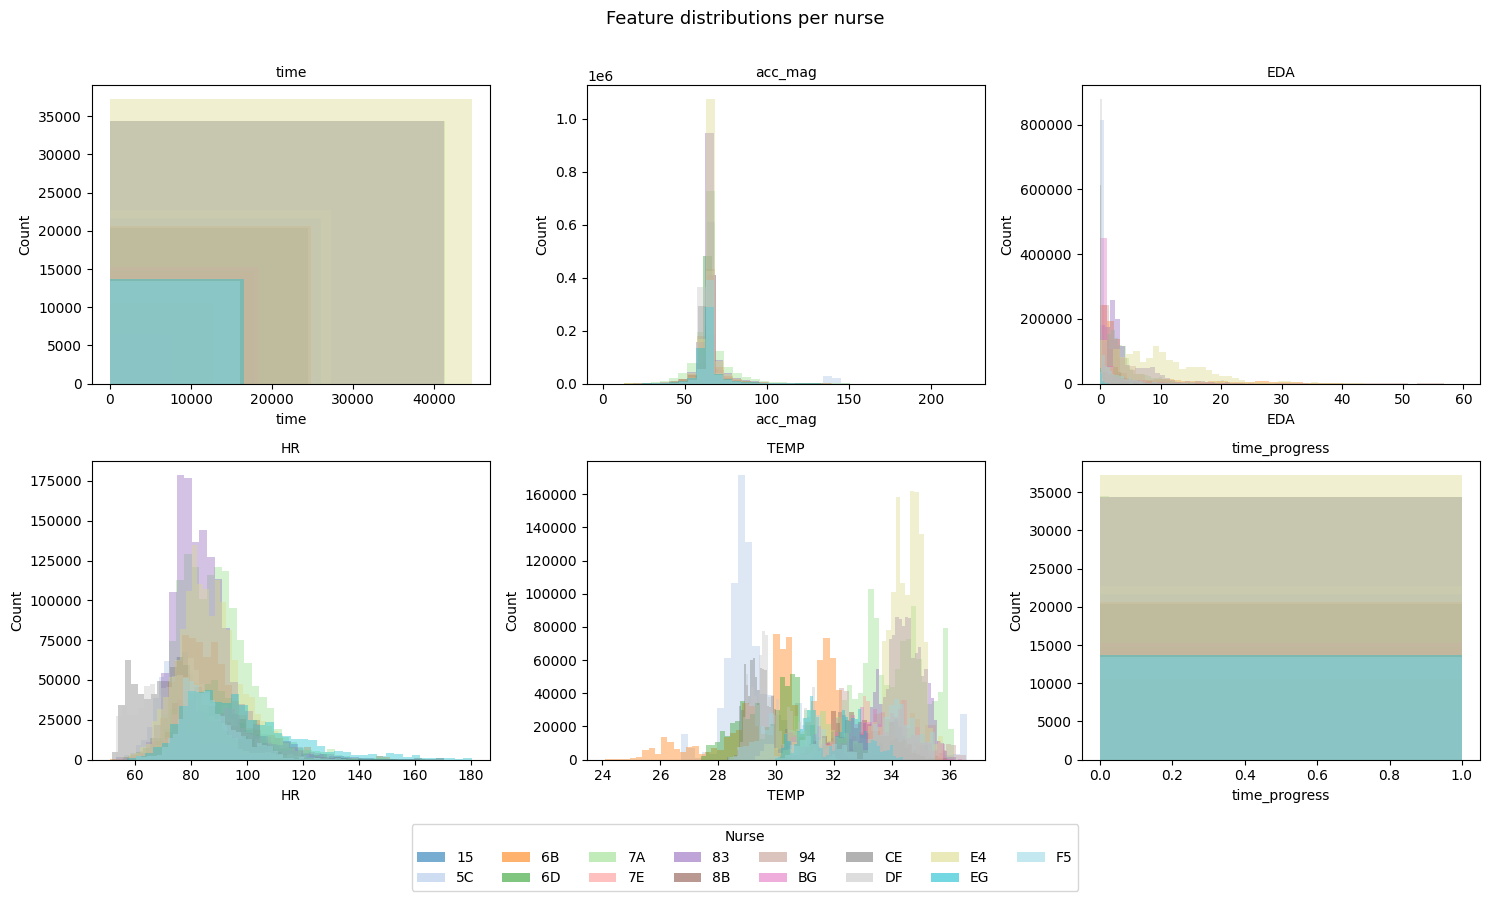

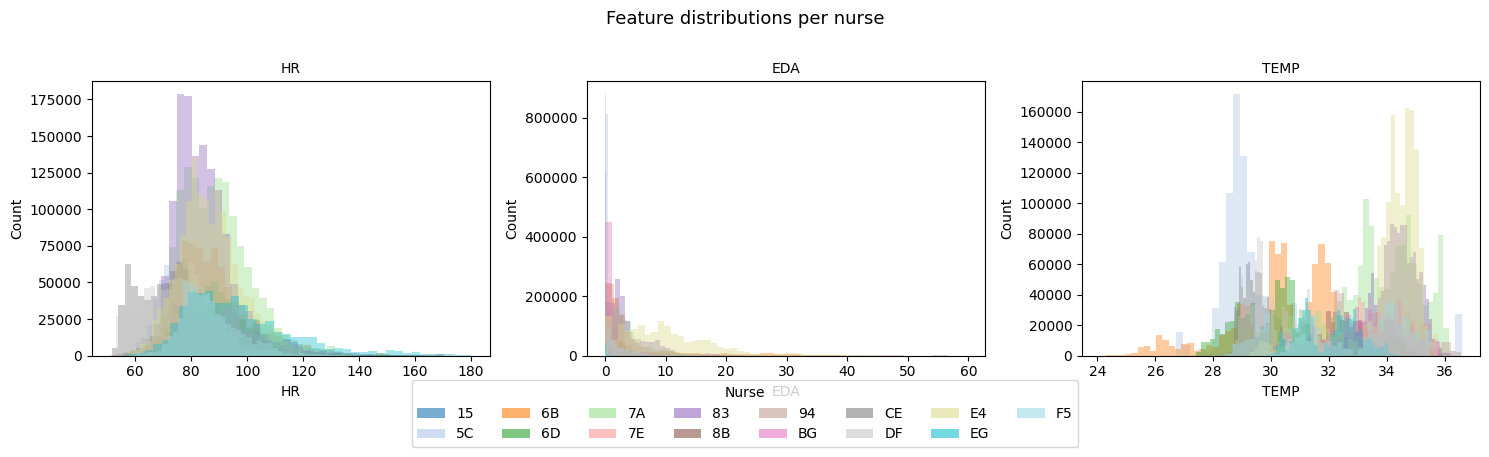

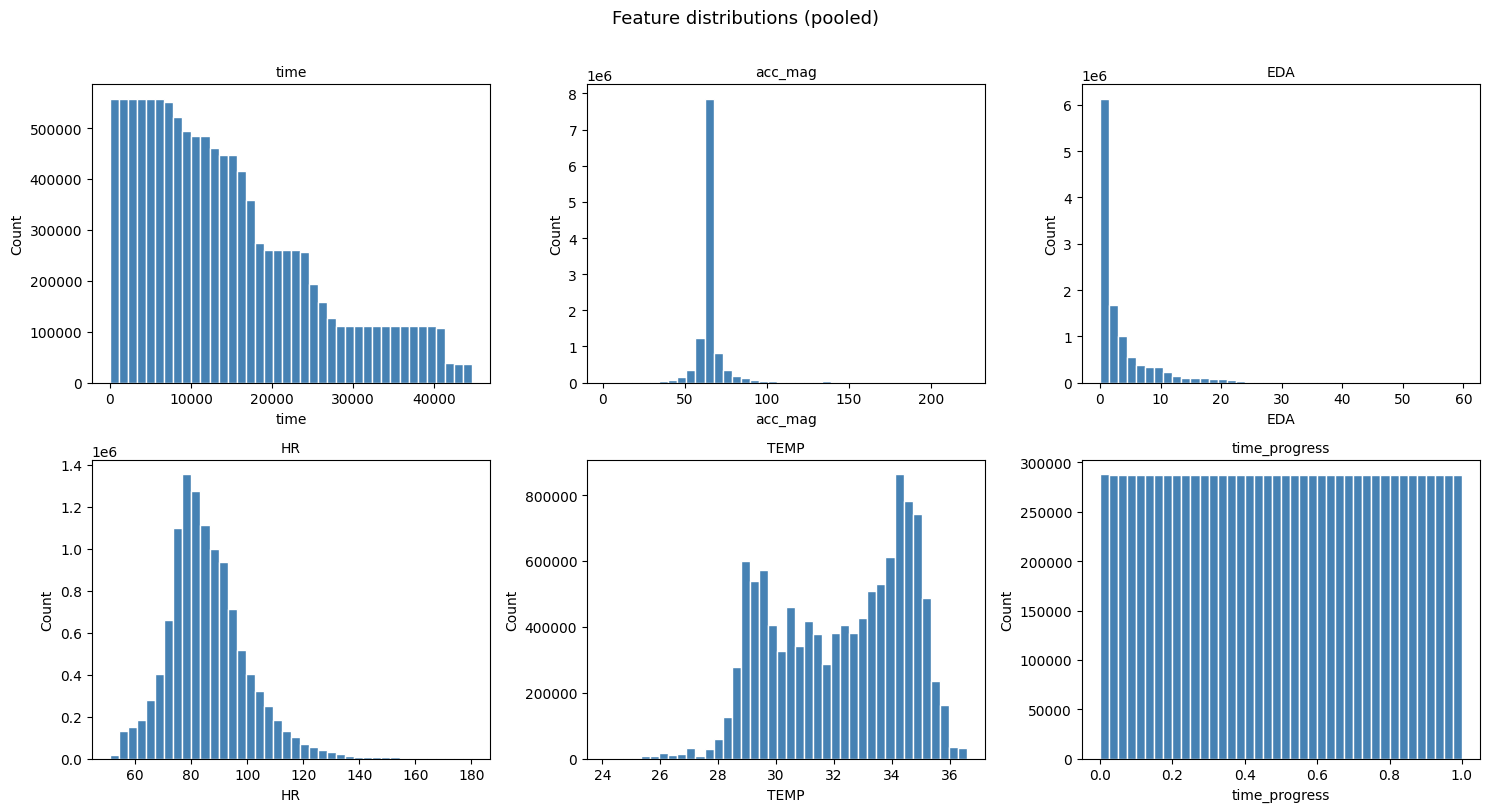

In [6]:
import glob, os
import matplotlib.pyplot as plt
import pandas as pd
import math

def plot_nurse_column_histograms(
    combined: pd.DataFrame,
    columns: list[str] = None,
    bins: int = 40,
    per_nurse: bool = True,
):
    """
    Plot histograms of numeric columns, one subplot per column.
    
    Args:
        combined:   DataFrame with a 'nurse_id' column (output of
                    plot_label_distribution).
        columns:    List of column names to plot. Defaults to all
                    numeric columns except 'label_binary'.
        bins:       Number of histogram bins.
        per_nurse:  If True, overlay a histogram trace per nurse.
                    If False, plot the pooled distribution.
    """
    if columns is None:
        columns = [
            c for c in combined.select_dtypes("number").columns
            if c not in ("label_binary", "label")
        ]

    nurse_ids = sorted(combined["nurse_id"].unique())
    cmap = plt.get_cmap("tab20")
    colors = {nid: cmap(i / max(len(nurse_ids) - 1, 1))
              for i, nid in enumerate(nurse_ids)}

    n_cols = 3
    n_rows = math.ceil(len(columns) / n_cols)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        squeeze=False,
    )

    for ax, col in zip(axes.flat, columns):
        if per_nurse:
            for nid in nurse_ids:
                data = combined.loc[combined["nurse_id"] == nid, col].dropna()
                ax.hist(
                    data, bins=bins, alpha=0.4,
                    color=colors[nid], label=str(nid),
                    edgecolor="none",
                )
        else:
            ax.hist(
                combined[col].dropna(), bins=bins,
                color="steelblue", edgecolor="white",
            )

        ax.set_title(col, fontsize=10)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

    # hide unused subplots
    for ax in axes.flat[len(columns):]:
        ax.set_visible(False)

    # shared legend outside the grid
    if per_nurse:
        handles = [
            plt.Rectangle((0, 0), 1, 1, fc=colors[nid], alpha=0.6)
            for nid in nurse_ids
        ]
        fig.legend(
            handles, nurse_ids,
            title="Nurse", loc="lower center",
            ncol=min(len(nurse_ids), 8),
            bbox_to_anchor=(0.5, -0.1),
        )

    plt.suptitle(
        "Feature distributions" +
        (" per nurse" if per_nurse else " (pooled)"),
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.show()


# ── Usage ────────────────────────────────────────────────────────────────────

# After calling plot_label_distribution, just pass 'combined':
plot_nurse_column_histograms(combined)

# Plot specific columns only:
plot_nurse_column_histograms(combined, columns=["HR", "EDA", "TEMP"])
plot_nurse_column_histograms(combined, per_nurse=False)


In [7]:
import os
import glob
from pyexpat import model
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from collections import defaultdict
from sklearn.metrics import average_precision_score

from google.colab import drive

# ── Config ────────────────────────────────────────────────────────────────────
# DATA_DIR   = "data/Eric"          # folder with one CSV per nurse
DATA_DIR = "/content/drive/My Drive/mlma"

FEATURES   = ["acc_mag", "EDA", "HR", "TEMP", "time_progress"]  # adjust to your cols
TARGET     = "label_binary"
TRAIN_FRAC = 0.7

VAL_FRAC   = 0.15

# MLP hyperparams
HIDDEN_DIMS  = [128, 64, 32]
DROPOUT      = 0.3
LR           = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS       = 50
BATCH_SIZE   = 256
PATIENCE     = 8                    # early stopping patience


# ── Model ─────────────────────────────────────────────────────────────────────

class StressMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list, dropout: float = 0.3):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))   # binary logit
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


# ── Helpers ───────────────────────────────────────────────────────────────────

def df_to_tensors(df, features=FEATURES, target=TARGET):
    """Convert a DataFrame split to (X, y) float32 / int64 tensors."""
    X = torch.tensor(df[features].values, dtype=torch.float32)
    y = torch.tensor(df[target].values,   dtype=torch.float32)
    return X, y


def make_loader_flat(df, batch_size=BATCH_SIZE, shuffle=True, oversample=False):
    """Point-wise (non-sequential) DataLoader — no sliding windows."""
    if len(df) == 0:
        return None
    X, y = df_to_tensors(df)
    if oversample and shuffle:
        counts    = np.bincount(y.long().numpy(), minlength=2).astype(float)
        counts    = np.where(counts == 0, 1, counts)
        w         = torch.tensor((1.0 / counts)[y.long().numpy()], dtype=torch.float32)
        sampler   = torch.utils.data.WeightedRandomSampler(w, len(w), replacement=True)
        return DataLoader(TensorDataset(X, y), batch_size=batch_size, sampler=sampler)
    return DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=shuffle)


def compute_pos_weight(train_df):
    """BCE pos_weight = #negatives / #positives (handles class imbalance)."""
    counts = train_df[TARGET].value_counts()
    neg, pos = counts.get(0, 1), counts.get(1, 1)
    return torch.tensor([neg / pos], dtype=torch.float32)


# ── Training loop ─────────────────────────────────────────────────────────────

def train_one_nurse(nurse_id: str, train_df, val_df, test_df, device):
    input_dim  = len(FEATURES)
    model      = StressMLP(input_dim, HIDDEN_DIMS, DROPOUT).to(device)
    pos_weight = compute_pos_weight(train_df).to(device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                     optimizer, patience=3, factor=0.5)

    train_loader = make_loader_flat(train_df, shuffle=True,  oversample=True)
    val_loader   = make_loader_flat(val_df,   shuffle=False, oversample=False)

    best_val_loss = float("inf")
    best_state    = None
    no_improve    = 0

    for epoch in range(1, EPOCHS + 1):
        # ── train ──
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * len(X_batch)
        train_loss /= len(train_loader.dataset)

        # ── validate ──
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss += criterion(model(X_batch), y_batch).item() * len(X_batch)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1

        if epoch % 10 == 0:
            print(f"  [{nurse_id}] epoch {epoch:3d} | "
                  f"train {train_loss:.4f} | val {val_loss:.4f}")

        if no_improve >= PATIENCE:
            print(f"  [{nurse_id}] early stop at epoch {epoch}")
            break

    # ── evaluate on test ──
    model.load_state_dict(best_state)
    model.eval()
    test_loader = make_loader_flat(test_df, shuffle=False, oversample=False)

    all_logits, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            all_logits.append(model(X_batch.to(device)).cpu())
            all_labels.append(y_batch)

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy().astype(int)
    preds  = (logits >= 0.0).astype(int)      # threshold at 0.5 in prob space

    report = classification_report(labels, preds, target_names=["no-stress", "stress"],
                                   output_dict=True, zero_division=0)
    try:
        auc = roc_auc_score(labels, logits)
        pr_auc = average_precision_score(labels, logits)
    except ValueError:
        auc = float("nan")
        pr_auc = float("nan")

    return model, best_state, report, auc, pr_auc                  # single class in test set


# ── Main: loop over all nurses ─────────────────────────────────────────────────

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}\n")

    csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
    csv_paths.remove(f"{DATA_DIR}/processed_nurse_6D.csv")
    csv_paths.remove(f"{DATA_DIR}/processed_nurse_CE.csv")
    csv_paths.remove(f"{DATA_DIR}/processed_nurse_EG.csv")
    assert csv_paths, f"No CSVs found in {DATA_DIR}"

    all_results = {}

    for path in csv_paths:
        nurse_id = os.path.splitext(os.path.basename(path))[0]
        print(f"── Nurse: {nurse_id} ──")

        df = load_nurse(path)
        train_df, val_df, test_df = day_split(df)
        train_df, val_df, test_df, _ = normalize_nurse(train_df, val_df, test_df)

        print(f"   train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}")

        if len(train_df) == 0 or len(test_df) == 0:
            print(f"   [SKIP] insufficient data\n")
            continue

        model, state, report, auc, pr_auc = train_one_nurse(
            nurse_id, train_df, val_df, test_df, device
        )
        all_results[nurse_id] = {"report": report, "auc": auc, "pr_auc": pr_auc}
        torch.save(state, f"model_{nurse_id}.pt")

        f1_stress = report["stress"]["f1-score"]
        print(f"   test AUC={auc:.3f}  stress-F1={f1_stress:.3f}\n")

    # ── Summary table ──
    print("\n═══ Summary ═══")
    print(f"{'Nurse':<20} {'AUC':>6} {'Stress-F1':>10} {'Accuracy':>10}")
    print("─" * 50)
    for nurse_id, res in all_results.items():
        r   = res["report"]
        acc = r["accuracy"]
        f1  = r["stress"]["f1-score"]
        auc = res["auc"]
        print(f"{nurse_id:<20} {auc:>6.3f} {f1:>10.3f} {acc:>10.3f}")
    rows = []
    for nurse_id, res in all_results.items():
        r = res["report"]
        rows.append({
            "nurse_id":         nurse_id,
            "auc":              res["auc"],
            "pr_auc":           res["pr_auc"],
            "f1_stress":        r["stress"]["f1-score"],
            "stress_precision": r["stress"]["precision"],
            "stress_recall":    r["stress"]["recall"],
            "no_stress_f1":     r["no-stress"]["f1-score"],
            "accuracy":         r["accuracy"],
            "model":            "MLP",
        })

    summary_df = pd.DataFrame(rows)
    summary_df.to_csv("/content/drive/My Drive/mlma/results_mlp.csv", index=False)

    print(summary_df.to_string(index=False))


if __name__ == "__main__":
    main()

Using device: cpu

── Nurse: processed_nurse_15 ──
   train=165,126  val=80,643  test=63,362
  [processed_nurse_15] early stop at epoch 9
   test AUC=0.460  stress-F1=0.881

── Nurse: processed_nurse_5C ──
   train=472,327  val=51,841  test=341,762
  [processed_nurse_5C] early stop at epoch 9
   test AUC=0.757  stress-F1=0.174

── Nurse: processed_nurse_6B ──
   train=328,263  val=401,284  test=96,002
  [processed_nurse_6B] epoch  10 | train 0.0000 | val 0.5815
  [processed_nurse_6B] early stop at epoch 13
   test AUC=0.735  stress-F1=0.649

── Nurse: processed_nurse_7A ──
   train=1,036,824  val=273,315  test=67,203
  [processed_nurse_7A] early stop at epoch 9
   test AUC=0.468  stress-F1=0.833

── Nurse: processed_nurse_7E ──
   train=115,203  val=32,641  test=105,603
  [processed_nurse_7E] epoch  10 | train 0.0006 | val 0.0001
  [processed_nurse_7E] early stop at epoch 16
   test AUC=0.176  stress-F1=0.130

── Nurse: processed_nurse_83 ──
   train=1,040,653  val=282,244  test=49,922

: 

EDA for nurse 15:
STD:  2.5321207230866762


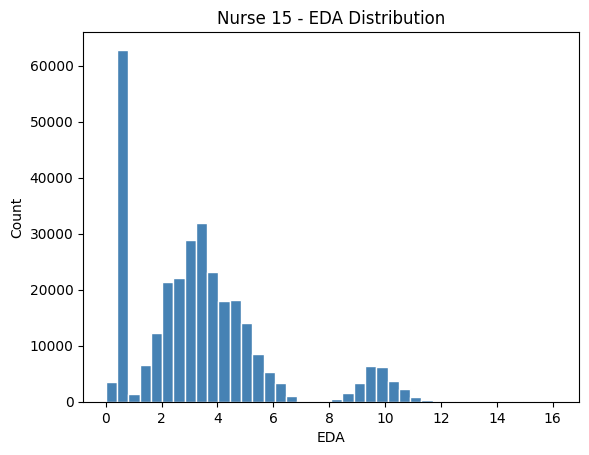

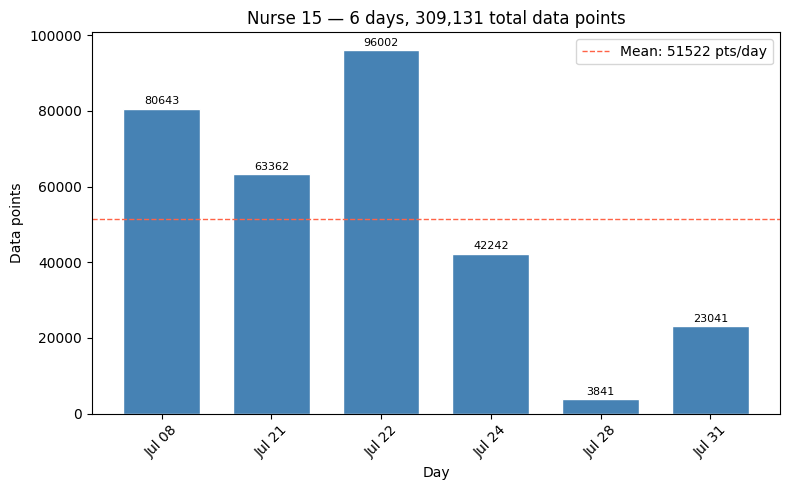

EDA for nurse 5C:
STD:  3.8375450494198557


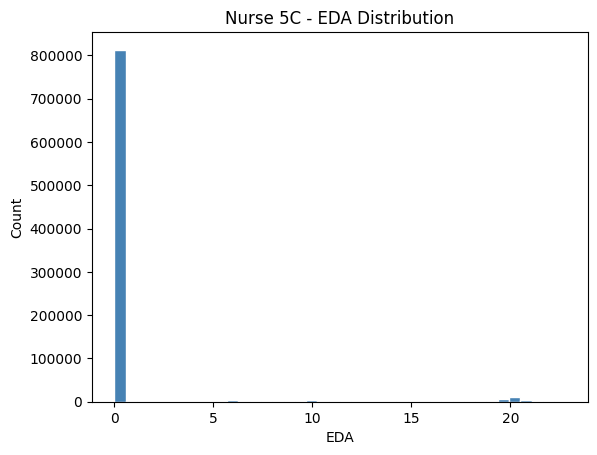

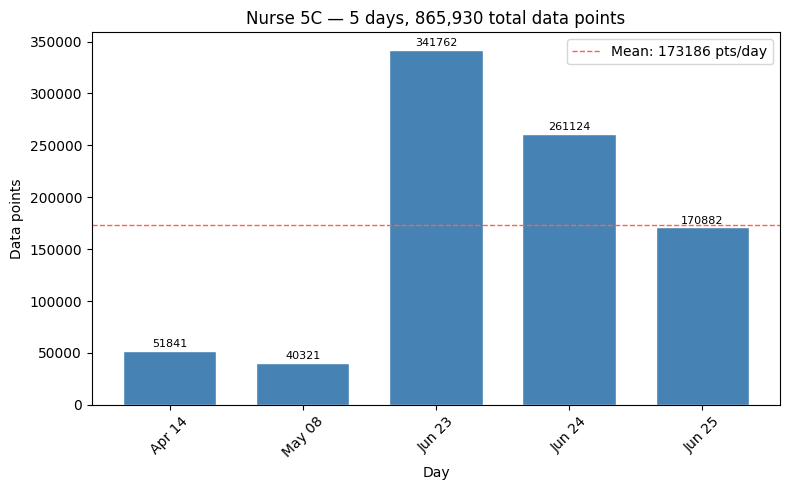

EDA for nurse 6B:
STD:  8.250475813931464


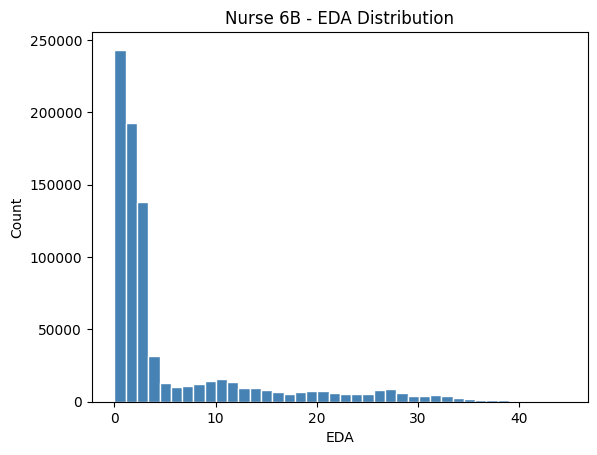

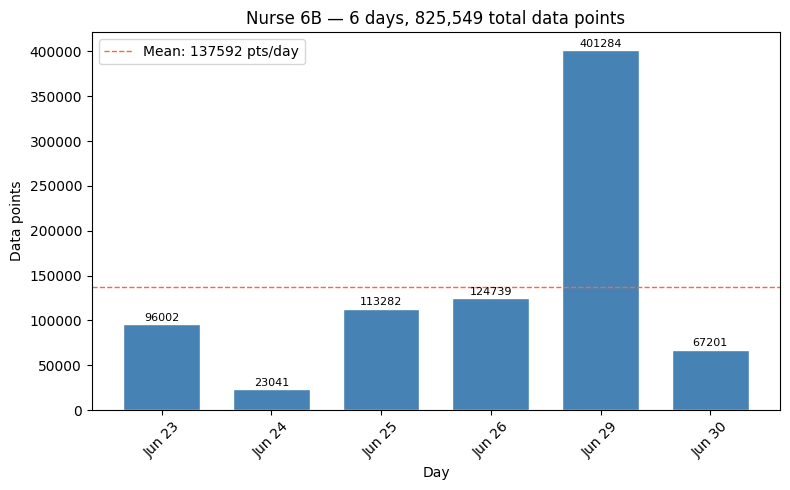

EDA for nurse 6D:
STD:  0.11851900572471026


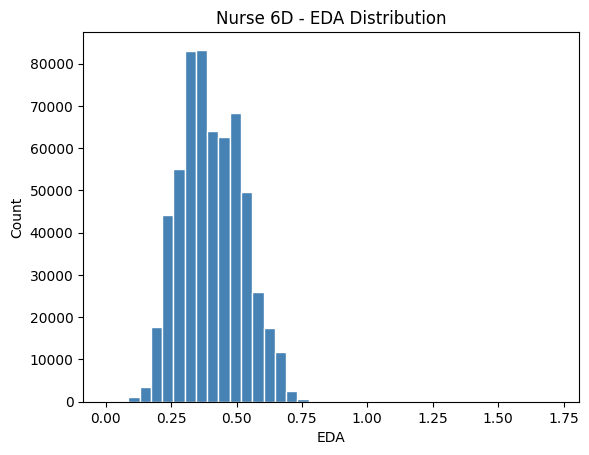

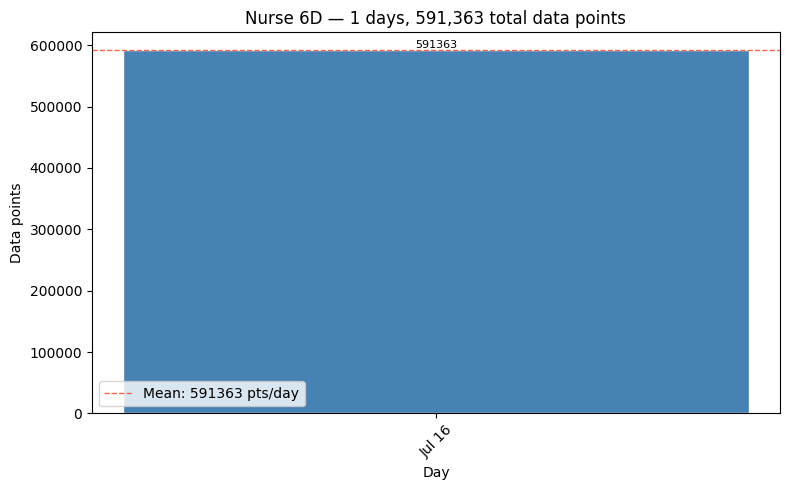

EDA for nurse 7A:
STD:  3.3969253663472565


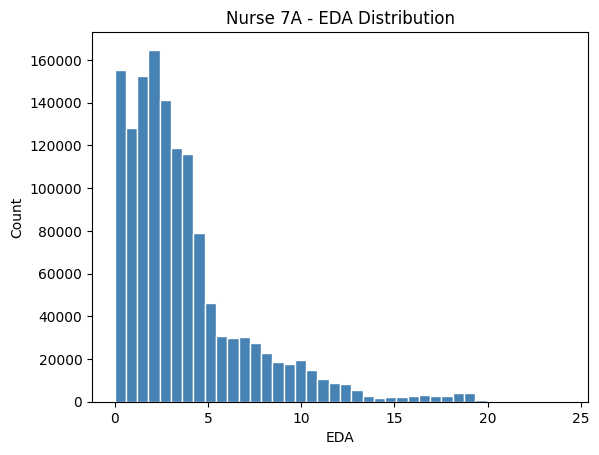

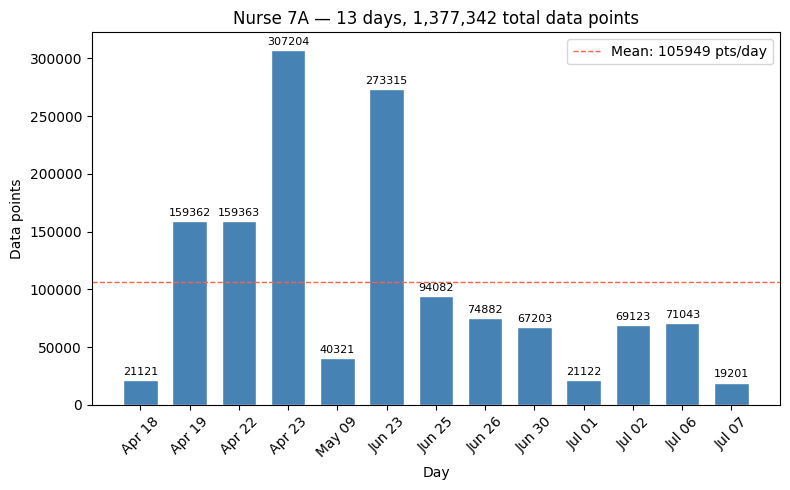

EDA for nurse 7E:
STD:  0.463292415954387


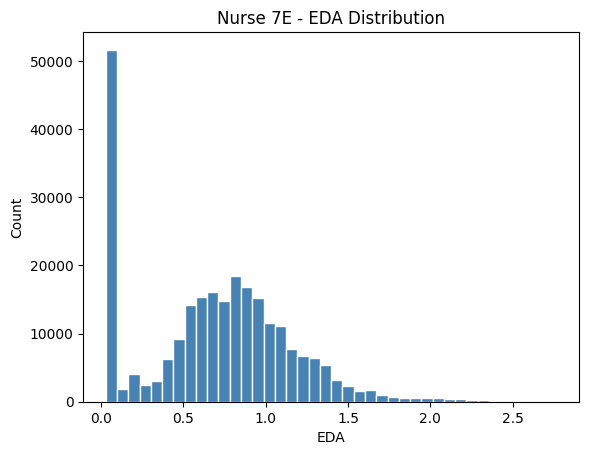

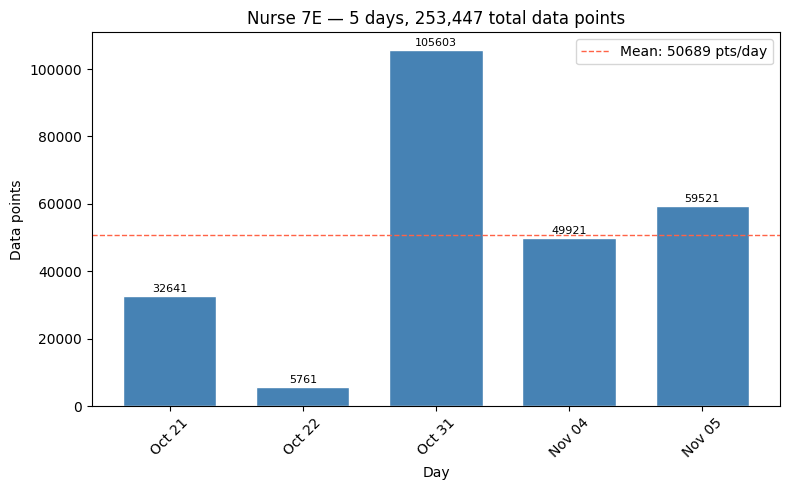

EDA for nurse 83:
STD:  4.082514321678325


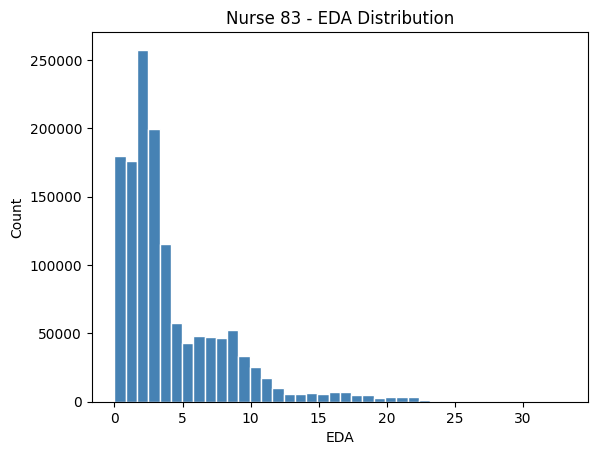

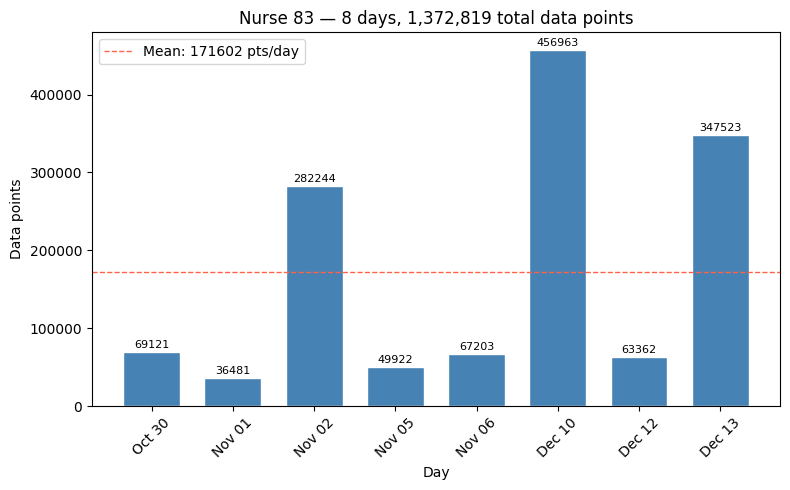

EDA for nurse 8B:
STD:  2.719627680352862


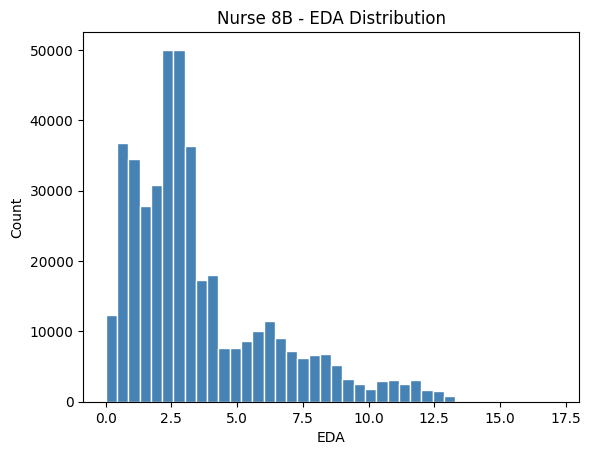

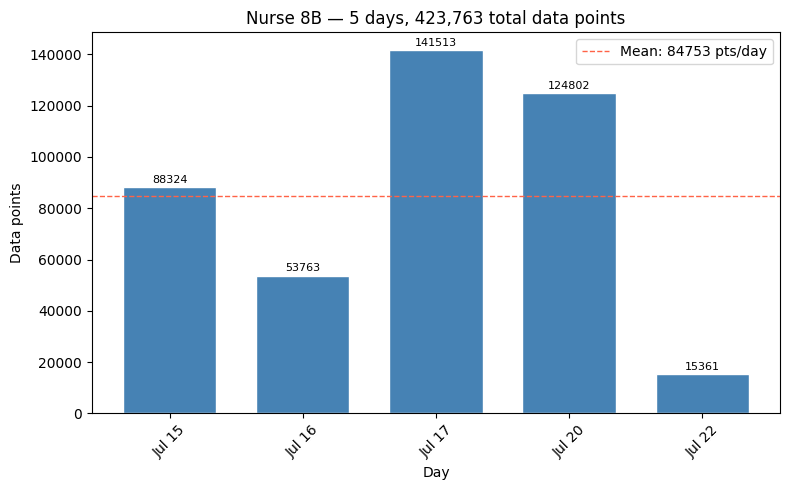

EDA for nurse 94:
STD:  8.661985029512728


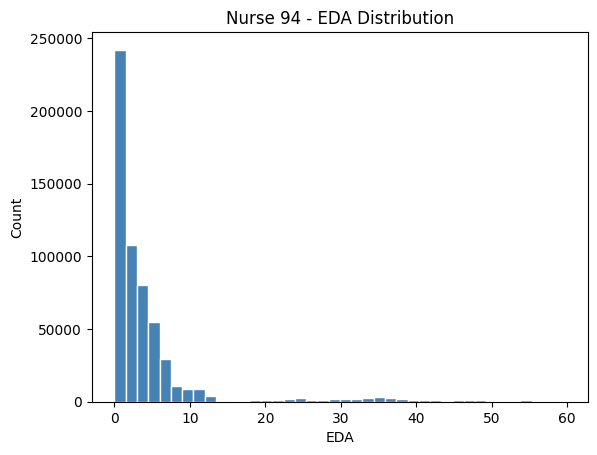

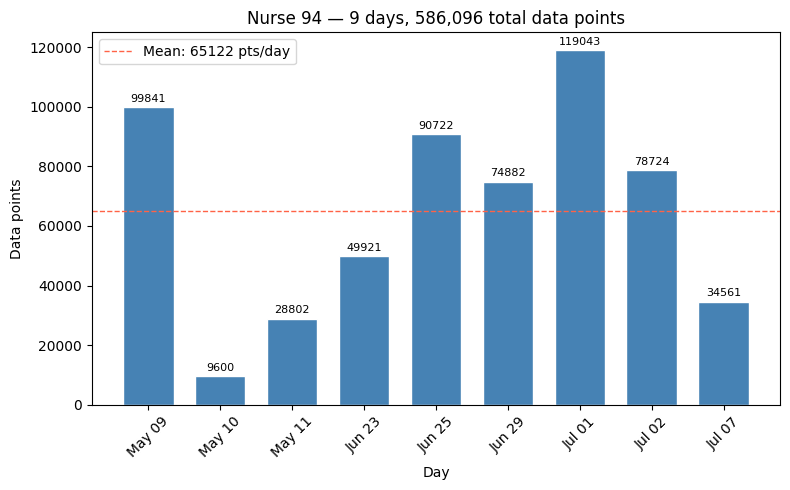

EDA for nurse BG:
STD:  4.288851577583985


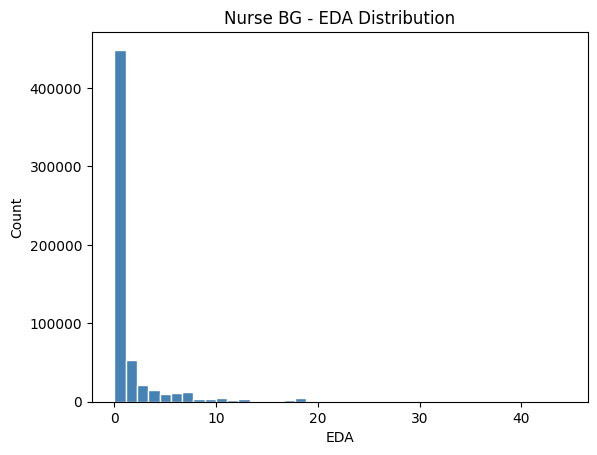

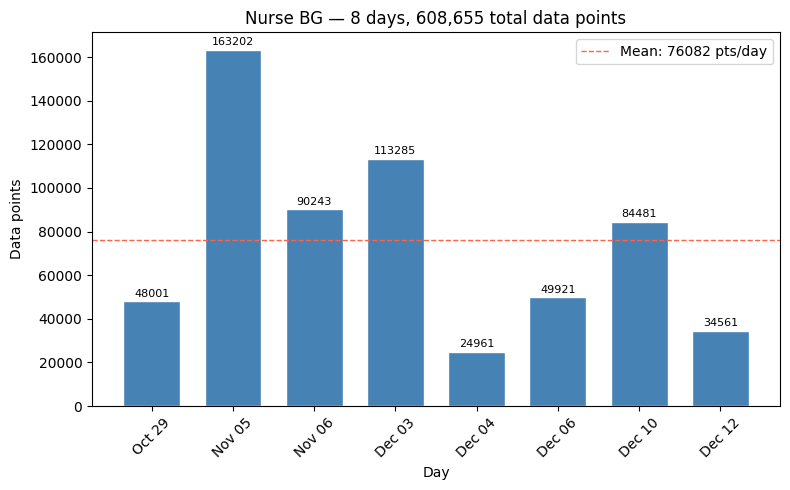

EDA for nurse CE:
STD:  0.058817015900692916


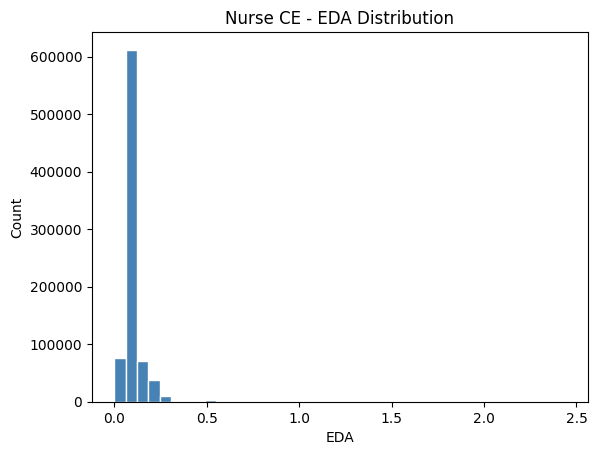

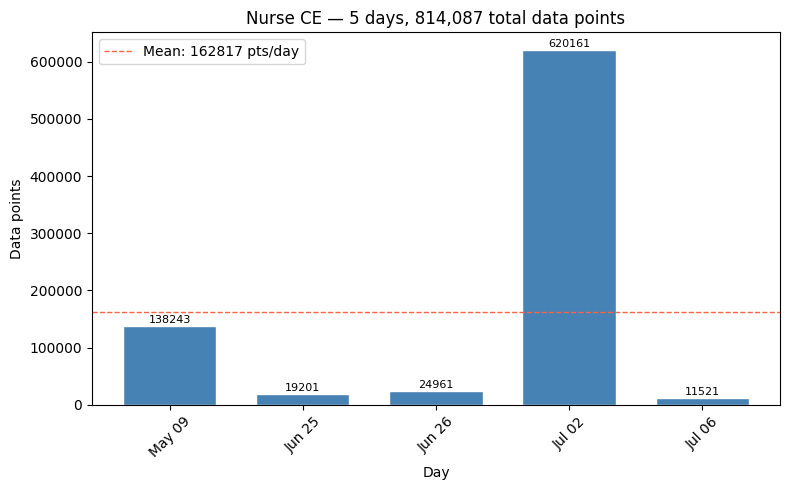

EDA for nurse DF:
STD:  0.45942386860035095


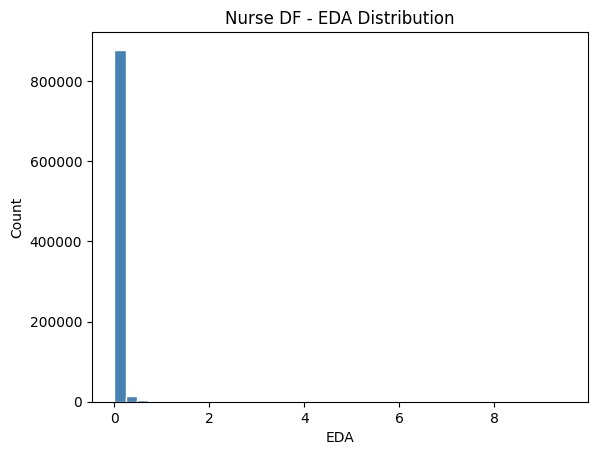

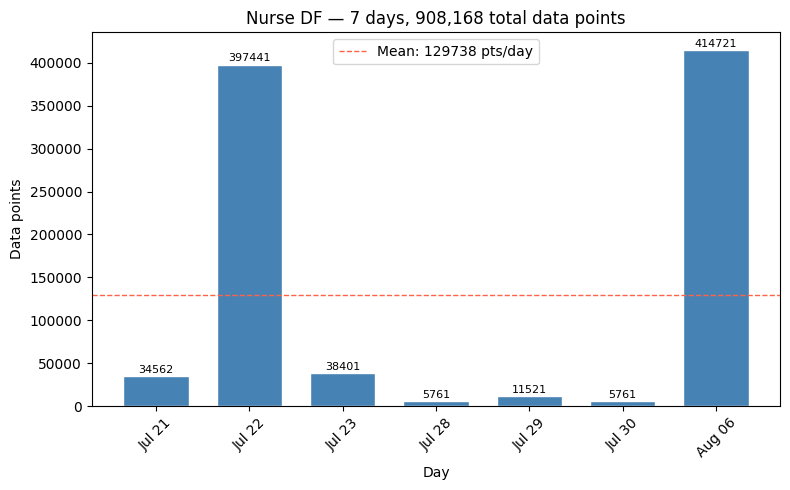

EDA for nurse E4:
STD:  7.64859902294125


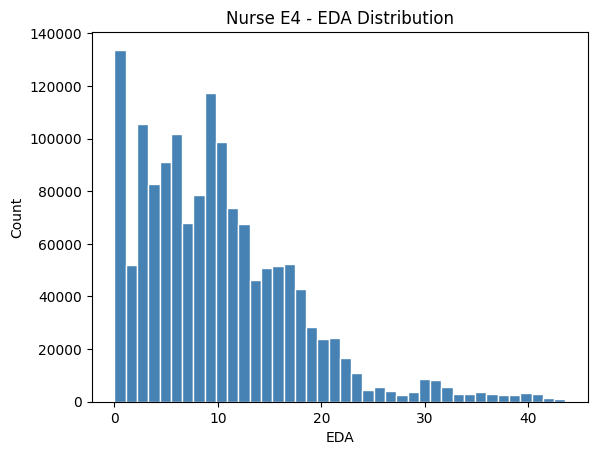

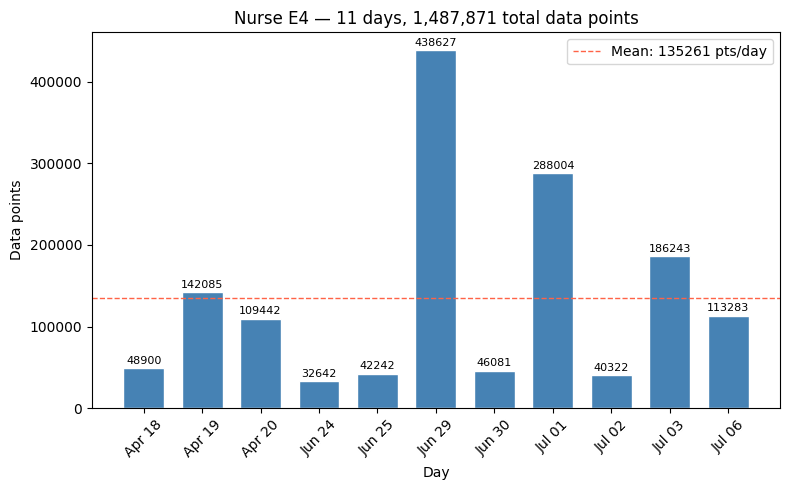

EDA for nurse EG:
STD:  0.22153604716185407


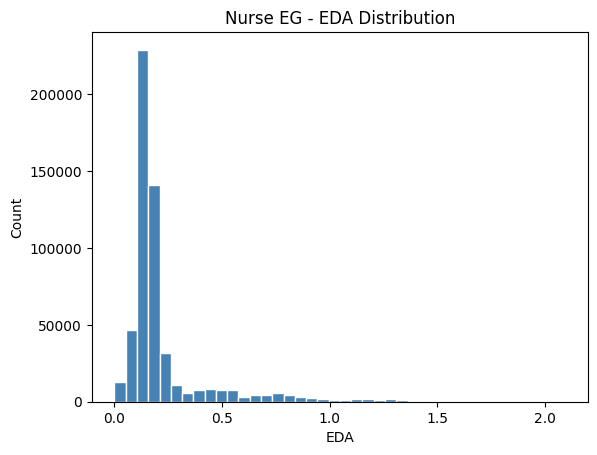

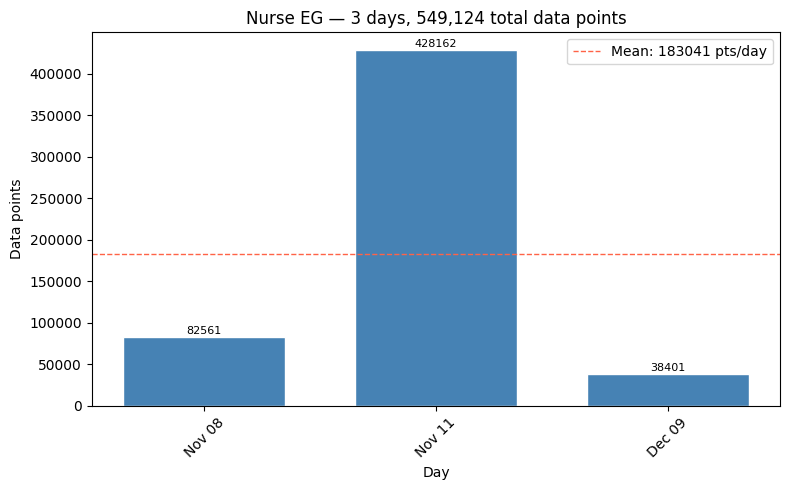

EDA for nurse F5:
STD:  2.8525457824278506


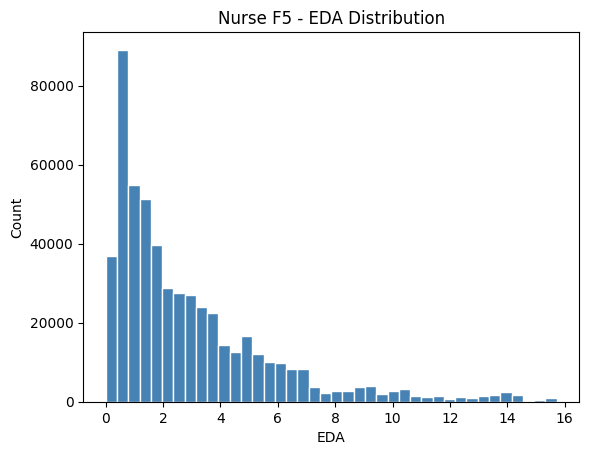

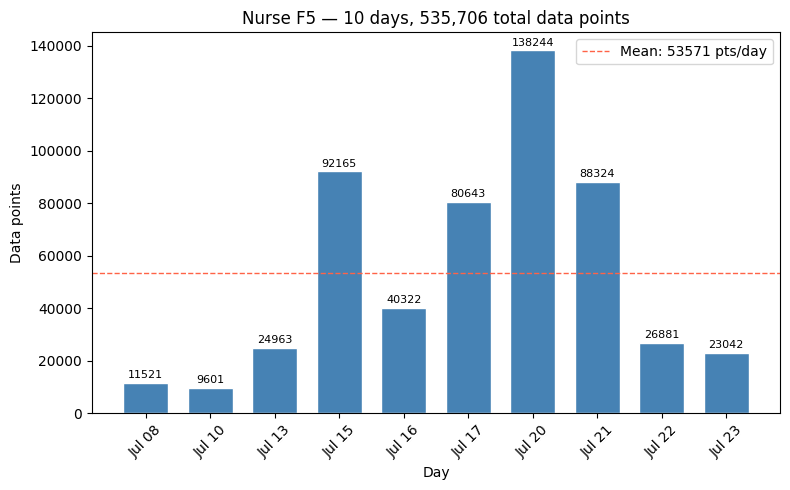

In [37]:
def plot_nurse_coverage(
    combined: pd.DataFrame,
    nurse_id: str,
    date_col: str = "date",
):
    """
    Bar plot for a single nurse: one bar per day, height = number of
    data points recorded that day.

    Args:
        combined:   DataFrame with 'nurse_id' and a date column.
        nurse_id:   ID of the nurse to inspect.
        date_col:   Name of the date column (default 'date').
    """
    nurse_data = combined[combined["nurse_id"] == nurse_id].copy()

    if nurse_data.empty:
        available = sorted(combined["nurse_id"].unique())
        raise ValueError(
            f"Nurse '{nurse_id}' not found. Available: {available}"
        )

    nurse_data[date_col] = pd.to_datetime(nurse_data[date_col]).dt.date

    daily_counts = (
        nurse_data.groupby(date_col)
        .size()
        .reset_index(name="n_points")
        .sort_values(date_col)
    )

    n_days   = len(daily_counts)
    n_total  = daily_counts["n_points"].sum()
    mean_pts = daily_counts["n_points"].mean()

    labels = pd.to_datetime(daily_counts[date_col]).dt.strftime("%b %d")

    fig, ax = plt.subplots(figsize=(max(8, n_days * 0.6), 5))

    bars = ax.bar(
        labels,
        daily_counts["n_points"],
        color="steelblue",
        edgecolor="white",
        width=0.7,
    )

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + n_total * 0.002,
            str(int(bar.get_height())),
            ha="center", va="bottom", fontsize=8,
        )

    ax.axhline(mean_pts, color="tomato", linestyle="--", linewidth=1,
               label=f"Mean: {mean_pts:.0f} pts/day")

    ax.set_title(
        f"Nurse {nurse_id} — {n_days} days, {n_total:,} total data points",
        fontsize=12,
    )
    ax.set_xlabel("Day")
    ax.set_ylabel("Data points")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    

    plt.tight_layout()
    plt.show()

    return daily_counts

def plot_nurse_eda(combined: pd.DataFrame,
    nurse_id: str):
    nurse_data = combined[combined["nurse_id"] == nurse_id].copy()
    plt.hist(nurse_data["EDA"].dropna(), bins=40, color="steelblue", edgecolor="white")
    print("STD: ", np.std(nurse_data["EDA"].dropna()))
    plt.title(f"Nurse {nurse_id} - EDA Distribution")
    plt.xlabel("EDA")
    plt.ylabel("Count")

    plt.show()

# ── Usage ─────────────────────────────────────────────────────────────────

# for nid in sorted(combined["nurse_id"].unique()):
#     print(f"Coverage for nurse {nid}:")
#     plot_nurse_coverage(combined, nurse_id=nid)

for nid in sorted(combined["nurse_id"].unique()):
    print(f"EDA for nurse {nid}:")
    plot_nurse_eda(combined, nurse_id=nid)
    plot_nurse_coverage(combined, nurse_id=nid)



In [25]:
import os
import glob
from pyexpat import model
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from collections import defaultdict
from sklearn.metrics import average_precision_score

from google.colab import drive

# ── Config ────────────────────────────────────────────────────────────────────
# DATA_DIR   = "data/Eric"          # folder with one CSV per nurse
DATA_DIR = "/content/drive/My Drive/mlma"

FEATURES   = ["acc_mag", "EDA", "HR", "TEMP", "time_progress"]  # adjust to your cols
TARGET     = "label_binary"
TRAIN_FRAC = 0.7

VAL_FRAC   = 0.15

# MLP hyperparams
HIDDEN_DIMS  = [128, 64, 32]
DROPOUT      = 0.3
LR           = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS       = 50
BATCH_SIZE   = 256
PATIENCE     = 8                    # early stopping patience


# ── Model ─────────────────────────────────────────────────────────────────────

class StressMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list, dropout: float = 0.3):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))   # binary logit
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


# ── Helpers ───────────────────────────────────────────────────────────────────

def df_to_tensors(df, features=FEATURES, target=TARGET):
    """Convert a DataFrame split to (X, y) float32 / int64 tensors."""
    X = torch.tensor(df[features].values, dtype=torch.float32)
    y = torch.tensor(df[target].values,   dtype=torch.float32)
    return X, y


def make_loader_flat(df, batch_size=BATCH_SIZE, shuffle=True, oversample=False):
    """Point-wise (non-sequential) DataLoader — no sliding windows."""
    if len(df) == 0:
        return None
    X, y = df_to_tensors(df)
    if oversample and shuffle:
        counts    = np.bincount(y.long().numpy(), minlength=2).astype(float)
        counts    = np.where(counts == 0, 1, counts)
        w         = torch.tensor((1.0 / counts)[y.long().numpy()], dtype=torch.float32)
        sampler   = torch.utils.data.WeightedRandomSampler(w, len(w), replacement=True)
        return DataLoader(TensorDataset(X, y), batch_size=batch_size, sampler=sampler)
    return DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=shuffle)


def compute_pos_weight(train_df):
    """BCE pos_weight = #negatives / #positives (handles class imbalance)."""
    counts = train_df[TARGET].value_counts()
    neg, pos = counts.get(0, 1), counts.get(1, 1)
    return torch.tensor([neg / pos], dtype=torch.float32)


# ── Training loop ─────────────────────────────────────────────────────────────

def train_one_nurse(nurse_id: str, train_df, val_df, test_df, device):
    input_dim  = len(FEATURES)
    model      = StressMLP(input_dim, HIDDEN_DIMS, DROPOUT).to(device)
    pos_weight = compute_pos_weight(train_df).to(device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                     optimizer, patience=3, factor=0.5)

    train_loader = make_loader_flat(train_df, shuffle=True,  oversample=True)
    val_loader   = make_loader_flat(val_df,   shuffle=False, oversample=False)

    best_val_loss = float("inf")
    best_state    = None
    no_improve    = 0

    for epoch in range(1, EPOCHS + 1):
        # ── train ──
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * len(X_batch)
        train_loss /= len(train_loader.dataset)

        # ── validate ──
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss += criterion(model(X_batch), y_batch).item() * len(X_batch)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1

        if epoch % 10 == 0:
            print(f"  [{nurse_id}] epoch {epoch:3d} | "
                  f"train {train_loss:.4f} | val {val_loss:.4f}")

        if no_improve >= PATIENCE:
            print(f"  [{nurse_id}] early stop at epoch {epoch}")
            break

    # ── evaluate on test ──
    model.load_state_dict(best_state)
    model.eval()
    test_loader = make_loader_flat(test_df, shuffle=False, oversample=False)

    all_logits, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            all_logits.append(model(X_batch.to(device)).cpu())
            all_labels.append(y_batch)

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy().astype(int)
    preds  = (logits >= 0.0).astype(int)      # threshold at 0.5 in prob space

    report = classification_report(labels, preds, target_names=["no-stress", "stress"],
                                   output_dict=True, zero_division=0)
    try:
        auc = roc_auc_score(labels, logits)
        pr_auc = average_precision_score(labels, logits)
    except ValueError:
        auc = float("nan")
        pr_auc = float("nan")

    return model, best_state, report, auc, pr_auc                  # single class in test set


# ── Main: loop over all nurses ─────────────────────────────────────────────────

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}\n")

    csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
    csv_paths.remove(f"{DATA_DIR}/processed_nurse_6D.csv")
    csv_paths.remove(f"{DATA_DIR}/processed_nurse_CE.csv")
    csv_paths.remove(f"{DATA_DIR}/processed_nurse_EG.csv")
    assert csv_paths, f"No CSVs found in {DATA_DIR}"

    all_results = {}

    for path in csv_paths:
        nurse_id = os.path.splitext(os.path.basename(path))[0]
        print(f"── Nurse: {nurse_id} ──")

        df = load_nurse(path)
        train_df, val_df, test_df = day_split(df)
        train_df, val_df, test_df, _ = normalize_nurse(train_df, val_df, test_df)

        print(f"   train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}")

        if len(train_df) == 0 or len(test_df) == 0:
            print(f"   [SKIP] insufficient data\n")
            continue

        model, state, report, auc, pr_auc = train_one_nurse(
            nurse_id, train_df, val_df, test_df, device
        )
        all_results[nurse_id] = {"report": report, "auc": auc, "pr_auc": pr_auc}
        torch.save(state, f"model_{nurse_id}.pt")

        f1_stress = report["stress"]["f1-score"]
        print(f"   test AUC={auc:.3f}  stress-F1={f1_stress:.3f}\n")

    # ── Summary table ──
    print("\n═══ Summary ═══")
    print(f"{'Nurse':<20} {'AUC':>6} {'Stress-F1':>10} {'Accuracy':>10}")
    print("─" * 50)
    for nurse_id, res in all_results.items():
        r   = res["report"]
        acc = r["accuracy"]
        f1  = r["stress"]["f1-score"]
        auc = res["auc"]
        print(f"{nurse_id:<20} {auc:>6.3f} {f1:>10.3f} {acc:>10.3f}")
    rows = []
    for nurse_id, res in all_results.items():
        r = res["report"]
        rows.append({
            "nurse_id":         nurse_id,
            "auc":              res["auc"],
            "pr_auc":           res["pr_auc"],
            "f1_stress":        r["stress"]["f1-score"],
            "stress_precision": r["stress"]["precision"],
            "stress_recall":    r["stress"]["recall"],
            "no_stress_f1":     r["no-stress"]["f1-score"],
            "accuracy":         r["accuracy"],
            "model":            "MLP",
        })

    summary_df = pd.DataFrame(rows)
    summary_df.to_csv("/content/drive/My Drive/mlma/results_mlp.csv", index=False)

    print(summary_df.to_string(index=False))


if __name__ == "__main__":
    main()

Using device: cpu

── Nurse: processed_nurse_15 ──
   train=165,126  val=80,643  test=63,362
  [processed_nurse_15] early stop at epoch 9
   test AUC=0.460  stress-F1=0.881

── Nurse: processed_nurse_5C ──
   train=472,327  val=51,841  test=341,762
  [processed_nurse_5C] early stop at epoch 9
   test AUC=0.757  stress-F1=0.174

── Nurse: processed_nurse_6B ──
   train=328,263  val=401,284  test=96,002
  [processed_nurse_6B] epoch  10 | train 0.0000 | val 0.5815
  [processed_nurse_6B] early stop at epoch 13
   test AUC=0.735  stress-F1=0.649

── Nurse: processed_nurse_7A ──
   train=1,036,824  val=273,315  test=67,203
  [processed_nurse_7A] early stop at epoch 9
   test AUC=0.468  stress-F1=0.833

── Nurse: processed_nurse_7E ──
   train=115,203  val=32,641  test=105,603
  [processed_nurse_7E] epoch  10 | train 0.0006 | val 0.0001
  [processed_nurse_7E] early stop at epoch 16
   test AUC=0.176  stress-F1=0.130

── Nurse: processed_nurse_83 ──
   train=1,040,653  val=282,244  test=49,922

In [7]:
def plot_f1_comparison(csv1_path, csv1_model, csv2_path, csv2_model, df3=None, df3_model=None):
    df1 = pd.read_csv(csv1_path); df1["model"] = csv1_model
    df1["nurse_id"] = df1["nurse_id"].str.replace(r"processed_nurse_", "", regex=True)

    df2 = pd.read_csv(csv2_path); df2["model"] = csv2_model
    df2["nurse_id"] = df2["nurse_id"].str.replace(r"processed_nurse_", "", regex=True)

    dfs = [df1[["nurse_id","f1_stress","model"]], 
           df2[["nurse_id","f1_stress","model"]]]
    if df3 is not None:
        dfs.append(df3[["nurse_id","f1_stress","model"]])

    combined = pd.concat(dfs, ignore_index=True)

    colors = {csv1_model: "steelblue", csv2_model: "tomato"}
    if df3_model:
        colors[df3_model] = "seagreen"

    fig, ax = plt.subplots(figsize=(12, 5))
    nurses = combined["nurse_id"].unique()
    
    for model, group in combined.groupby("model"):
        ax.scatter(group["nurse_id"], group["f1_stress"],
                   color=colors.get(model, "gray"), label=model,
                   s=80, edgecolors="black", linewidths=0.5, alpha = 0.6)

    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title("Stress F1 Score by Nurse and Model")
    ax.set_xlabel("Nurse ID")
    ax.set_ylabel("F1 Score (Stress)")
    ax.set_ylim(0, 1)
    ax.legend(title="Model")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [27]:
import pandas as pd
import numpy as np

def summarize_metrics_table(csv1_path, csv1_model, csv2_path, csv2_model, df3=None, df3_model=None):
    """
    Creates a comparison table of average metric values across nurses for each model.
    
    Only metrics shared by all provided models are included.
    Assumes rows are per nurse and numeric metric columns should be averaged.
    """

    # Load first two CSVs
    df1 = pd.read_csv(csv1_path)
    df1["model"] = csv1_model
    df1["nurse_id"] = df1["nurse_id"].astype(str).str.replace(
        r"processed_nurse_", "", regex=True
    )

    df2 = pd.read_csv(csv2_path)
    df2["model"] = csv2_model
    df2["nurse_id"] = df2["nurse_id"].astype(str).str.replace(
        r"processed_nurse_", "", regex=True
    )

    dfs = [(df1, csv1_model), (df2, csv2_model)]

    if df3 is not None and df3_model is not None:
        df3 = df3.copy()
        df3["model"] = df3_model
        df3["nurse_id"] = df3["nurse_id"].astype(str).str.replace(
            r"processed_nurse_", "", regex=True
        )
        dfs.append((df3, df3_model))

    # Find numeric columns for each dataframe
    metric_sets = []
    for df, _ in dfs:
        numeric_cols = set(df.select_dtypes(include=np.number).columns)
        numeric_cols.discard("nurse_id")
        metric_sets.append(numeric_cols)

    # Keep only metrics common to all models
    common_metrics = sorted(set.intersection(*metric_sets))

    if not common_metrics:
        raise ValueError("No shared numeric metrics found across all models.")

    # Compute averages
    rows = []
    for df, model_name in dfs:
        means = df[common_metrics].mean()
        row = {"model": model_name}
        row.update(means.to_dict())
        rows.append(row)

    result = pd.DataFrame(rows)

    # Format nicely
    result = result.set_index("model").round(3)

    # Optional: sort columns alphabetically
    result = result[sorted(result.columns)]

    return result


In [ ]:
def aggregate_folds(csv_path, model_name_filter, output_model_name):
    """
    Average metrics across folds, one row per nurse.

    Robust version:
    - Includes precision_stress / recall_stress
    - Handles missing auc columns safely
    - Falls back to balanced_accuracy if needed
    """

    import pandas as pd
    import re

    df = pd.read_csv(csv_path)
    df = df[df["model"] == model_name_filter].copy()

    # -------------------------
    # normalize helper
    # -------------------------
    def norm(col):
        return re.sub(r"[^a-z0-9]+", "_", str(col).lower()).strip("_")

    # -------------------------
    # fuzzy find columns
    # -------------------------
    precision_col = None
    recall_col = None
    auc_col = None
    f1_col = None

    for col in df.columns:
        c = norm(col)

        if f1_col is None and ("f1" in c and ("stress" in c or "binary" in c)):
            f1_col = col

        if precision_col is None and ("precision" in c and ("stress" in c or "binary" in c)):
            precision_col = col

        if recall_col is None and ("recall" in c and ("stress" in c or "binary" in c)):
            recall_col = col

        if auc_col is None and c in [
            "auc",
            "roc_auc",
            "pr_auc",
            "balanced_accuracy",
        ]:
            auc_col = col

    # explicit fallbacks
    if f1_col is None:
        for c in ["f1_binary", "f1_stress", "f1"]:
            if c in df.columns:
                f1_col = c
                break

    # -------------------------
    # Build aggregation safely
    # -------------------------
    agg_map = {}

    if f1_col:
        agg_map["f1_stress"] = (f1_col, "mean")

    if "accuracy" in df.columns:
        agg_map["accuracy"] = ("accuracy", "mean")

    if auc_col:
        agg_map["auc"] = (auc_col, "mean")

    if precision_col:
        agg_map["precision_stress"] = (precision_col, "mean")

    if recall_col:
        agg_map["recall_stress"] = (recall_col, "mean")

    if not agg_map:
        raise ValueError("No usable metric columns found.")

    # -------------------------
    # Aggregate
    # -------------------------
    aggregated = df.groupby("nurse_id").agg(**agg_map).reset_index()

    aggregated["model"] = output_model_name

    return aggregated

In [17]:
dt_agg = aggregate_folds(f"{DATA_DIR}/results/cv_fold_model_metrics.csv", model_name_filter="decision_tree", output_model_name="Decision Tree")

summarize_metrics_table(
    f"{DATA_DIR}/results/results_mlp.csv", "MLP",
    f"{DATA_DIR}/results/nurse_results_summary.csv",          "LSTM",
    df3=dt_agg,                  df3_model="Decision Tree"
)

,accuracy,f1_stress
model,,
MLP,0.512,0.586
LSTM,0.499,0.382
Decision Tree,0.444,0.448


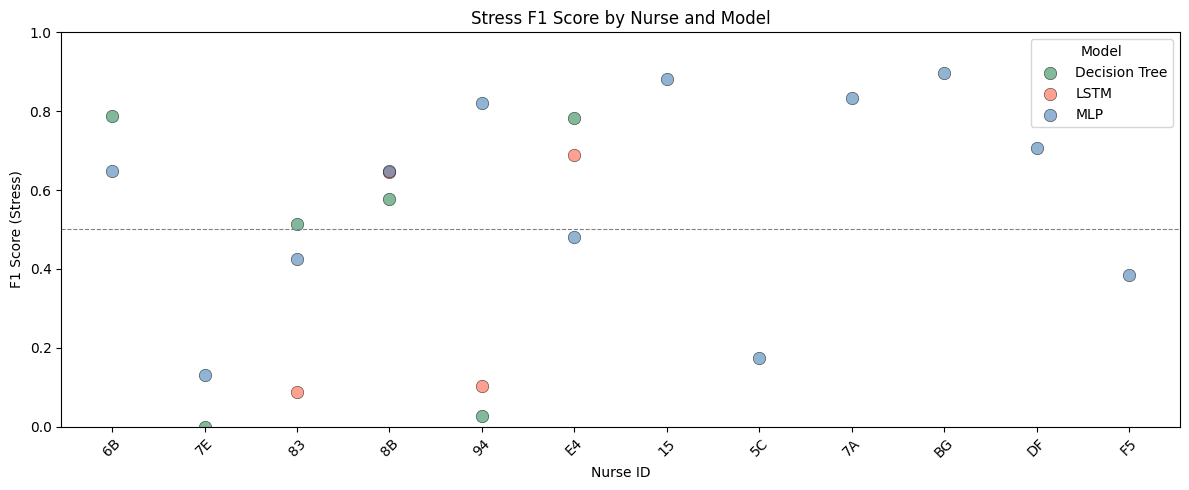

In [12]:
dt_agg = aggregate_folds(f"{DATA_DIR}/results/cv_fold_model_metrics.csv", model_name_filter="decision_tree", output_model_name="Decision Tree")

plot_f1_comparison(
    f"{DATA_DIR}/results/results_mlp.csv", "MLP",
    f"{DATA_DIR}/results/nurse_results_summary.csv",          "LSTM",
    df3=dt_agg,                  df3_model="Decision Tree"
)